In [1]:
%run ./utils.ipynb

In [2]:
import itertools
import os.path
import rospy
from PyKDL import Frame, Rotation, Vector
import pickle

from robot_command.interfaces.joints_to_pose_interface import (
    JointsToPoseInterface,
)

def print_deviations(trajectory):
    poses_in = [
        joints_to_pose.get_pose_from_joint_values(point.positions[:6])
        for point in trajectory.joint_trajectory.points
    ]
    start_pose = poses_in[0]
    deviations = [
        (
            start_pose.position.x - pose.position.x,
            start_pose.position.y - pose.position.y,
            start_pose.position.z - pose.position.z,
        )
        for pose in poses_in
    ]
    for dev in deviations:
        print(dev)

def print_tcp_distance(trajectory):
    poses_in = [
        joints_to_pose.get_pose_from_joint_values(point.positions[:6])
        for point in trajectory.joint_trajectory.points
    ]
    frames = [
        Frame(
            Rotation.Quaternion(
                p.orientation.x, p.orientation.y, p.orientation.z, p.orientation.w
            ),
            Vector(p.position.x, p.position.y, p.position.z),
        )
        for p in poses_in
    ]
    tcp_pos = 0.0
    tcp_rot = 0.0
    tcp_lin = [0.0]
    tcp_rot = [0.0]
    #rot_interp = RotationalInterpolationSingleAxis()
    for i in range(1, len(frames)):
        diff = frames[i] * frames[i-1].Inverse()
        tcp_pos += diff.p.Norm()
        tcp_lin.append(tcp_pos)
    print(tcp_lin)
    tcp_vel = [0.0]
    tcp_vel.extend(tcp_lin[i] - tcp_lin[i-1] for i in range(1, len(tcp_lin)))
    print(tcp_vel)

def print_limits():
    def get_limits(name):
        accel = rospy.get_param(
            f'/robot_description_planning/joint_limits/{name}/max_acceleration'
        )
        vel = rospy.get_param(
            f'/robot_description_planning/joint_limits/{name}/max_velocity'
        )
        return vel, accel

    limits = [get_limits(f'joint_{i}') for i in range(1, 7)]
    print(limits)

def print_max_vels_and_accels(trajectory):
    n_joints = len(trajectory.joint_trajectory.points[0].positions)
    last_pos = list(trajectory.joint_trajectory.points[0].positions)
    last_vel = [0.0] * n_joints
    max_vels = [0.0] * n_joints
    max_accels = [0.0] * n_joints
    max_vels_calc = [0.0] * n_joints
    max_accels_calc = [0.0] * n_joints
    last_time = [trajectory.joint_trajectory.points[0].time_from_start] * n_joints
    for point, i in itertools.product(
        trajectory.joint_trajectory.points, range(n_joints)
    ):
        max_vels[i] = max(abs(point.velocities[i]), max_vels[i])
        max_accels[i] = max(abs(point.accelerations[i]), max_accels[i])
        time_diff = point.time_from_start - last_time[i]
        vel = (point.positions[i] - last_pos[i]) / max(1e-9, time_diff.to_sec())
        accel = (last_vel[i] - vel) / max(1e-9, time_diff.to_sec())
        max_vels_calc[i] = max(abs(vel), max_vels_calc[i])
        max_accels_calc[i] = max(abs(accel), max_accels_calc[i])
        last_pos[i] = point.positions[i]
        last_vel[i] = vel
        last_time[i] = point.time_from_start
    print(max_vels)
    print(max_vels_calc)
    print(max_accels)
    print(max_accels_calc)

In [3]:
with open(os.path.expanduser('~/in_traj.pickle'), 'rb') as f:
    trajectory_in = pickle.load(f).joint_trajectory
print(type(trajectory_in))

<class 'trajectory_msgs.msg._JointTrajectory.JointTrajectory'>


In [4]:
with open(os.path.expanduser('~/tmp/execute_traj.pickle'), 'rb') as f:
    trajectory_exec = pickle.load(f)
print(type(trajectory_in))

<class 'trajectory_msgs.msg._JointTrajectory.JointTrajectory'>


In [5]:
with open(os.path.expanduser('~/tmp/cmd_traj.pickle'), 'rb') as f:
    trajectory_in2 = pickle.load(f)
print(type(trajectory_in))
#print(trajectory_in)
times_in = [point.time_from_start.to_sec() for point in trajectory_in.points]

<class 'trajectory_msgs.msg._JointTrajectory.JointTrajectory'>


In [6]:
with open(os.path.expanduser('~/tmp/joint_states.pickle'), 'rb') as f:
    trajectory_out = pickle.load(f)
print(type(trajectory_out))
#print(trajectory_out)
first_timestamp = trajectory_out[0].header.stamp.to_sec()
times_out = [(s.header.stamp.to_sec() - first_timestamp)for s in trajectory_out]

<class 'list'>


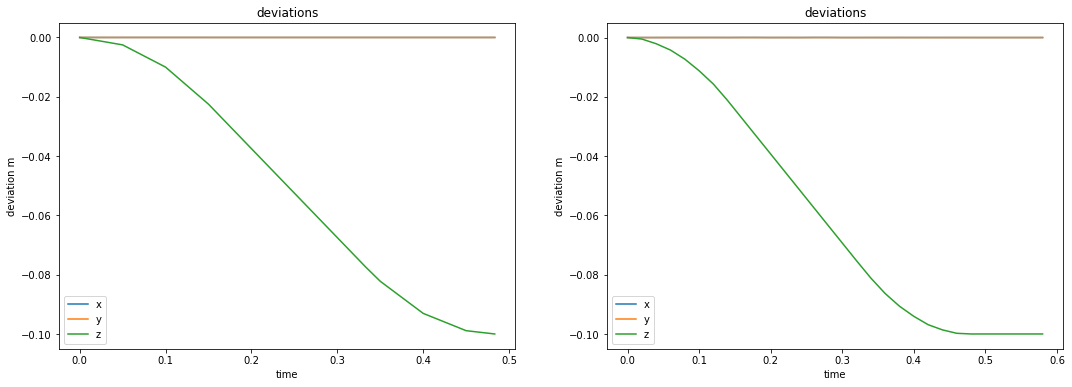

In [7]:
from matplotlib import pyplot as plt
import numpy as np
#%matplotlib notebook

def find_deviations(points):
    poses_in = [
        joints_to_pose.get_pose_from_joint_values(point[:6])
        for point in points
    ]
    start_pose = poses_in[0]
    deviations = [
        (
            start_pose.position.x - pose.position.x,
            start_pose.position.y - pose.position.y,
            start_pose.position.z - pose.position.z,
        )
        for pose in poses_in
    ]
    return deviations

plt.rcParams['figure.figsize'] = (18, 6)
fig, (ax1, ax2) = plt.subplots(1, 2)

devs = find_deviations([p.positions for p in trajectory_in.points])
#fig = plt.figure()
#ax = fig.add_axes([0,0,1,1])
ax = ax1
times = times_in
ax.plot(times, [dev[0] for dev in devs], label="x")
ax.plot(times, [dev[1] for dev in devs], label="y")
ax.plot(times, [dev[2] for dev in devs], label="z")
ax.set_title("deviations")
ax.set_xlabel("time")
ax.set_ylabel("deviation m")
ax.legend()

devs = find_deviations([s.position for s in trajectory_out])
#fig = plt.figure()
#ax = fig.add_axes([0,0,1,1])
ax = ax2
times = times_out
ax.plot(times, [dev[0] for dev in devs], label="x")
ax.plot(times, [dev[1] for dev in devs], label="y")
ax.plot(times, [dev[2] for dev in devs], label="z")
ax.set_title("deviations")
ax.set_xlabel("time")
ax.set_ylabel("deviation m")
ax.legend()

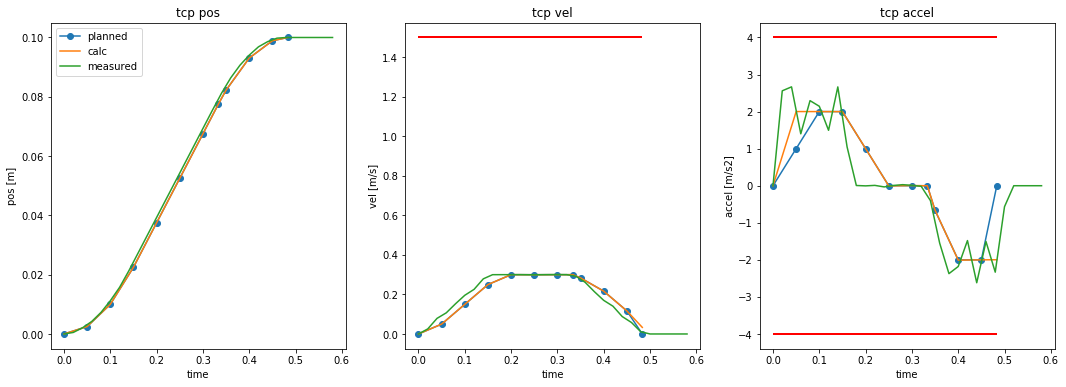

In [8]:
times, (tcp_lin, tcp_vel, tcp_accel) = calc_tcp_distance(trajectory_in)
tcp_lino, tcp_velo, tcp_accelo = calc_tcp_distance2(times_out, [s.position for s in trajectory_out])

max_vel = rospy.get_param("/robot_description_planning/cartesian_limits/max_trans_vel")
max_acc = rospy.get_param("/robot_description_planning/cartesian_limits/max_trans_acc")
max_dec = rospy.get_param("/robot_description_planning/cartesian_limits/max_trans_dec")

plt.rcParams['figure.figsize'] = (18, 6)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
#fig = plt.figure()
#ax = fig.add_axes([0,0,1,1])
ax = ax1
ax.plot(times, [p.positions[6] for p in trajectory_in.points], label="planned", marker="o")
ax.plot(times, tcp_lin, label="calc")
ax.plot(times_out, tcp_lino, label="measured")
ax.set_title("tcp pos")
ax.set_xlabel("time")
ax.set_ylabel("pos [m]")
ax.legend()

#fig = plt.figure()
#ax = fig.add_axes([0,0,1,1])
ax = ax2
ax.plot(times, [p.velocities[6] for p in trajectory_in.points], marker="o")
ax.plot(times, tcp_vel, label="vel")
ax.plot(times_out, tcp_velo)
ax.set_title("tcp vel")
ax.set_xlabel("time")
ax.set_ylabel("vel [m/s]")
ax.hlines(y=max_vel, xmin=times[0], xmax=times[-1], linewidth=2, color='r')

#fig = plt.figure()
#ax = fig.add_axes([0,0,1,1])
ax = ax3
ax.plot(times, [p.accelerations[6] for p in trajectory_in.points], marker="o")
ax.plot(times, tcp_accel, label="accel")
ax.plot(times_out, tcp_accelo)
ax.set_title("tcp accel")
ax.set_xlabel("time")
ax.set_ylabel("accel [m/s2]")
ax.hlines(y=max_acc, xmin=times[0], xmax=times[-1], linewidth=2, color='r')
ax.hlines(y=max_dec, xmin=times[0], xmax=times[-1], linewidth=2, color='r')

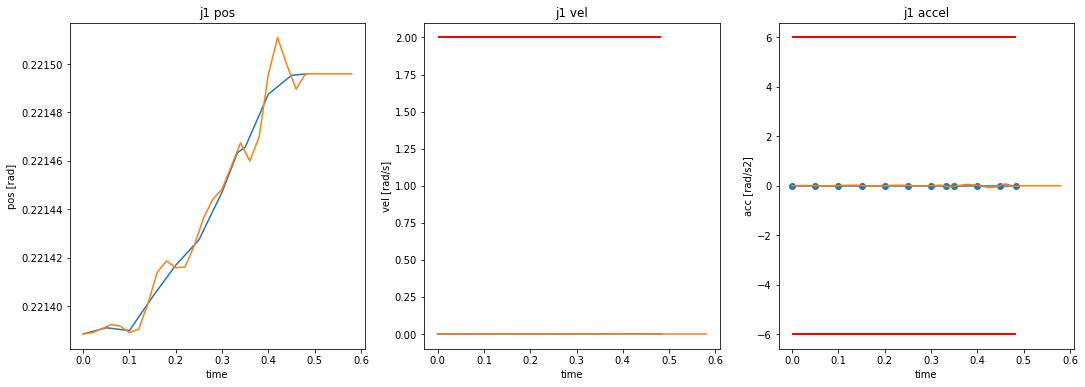

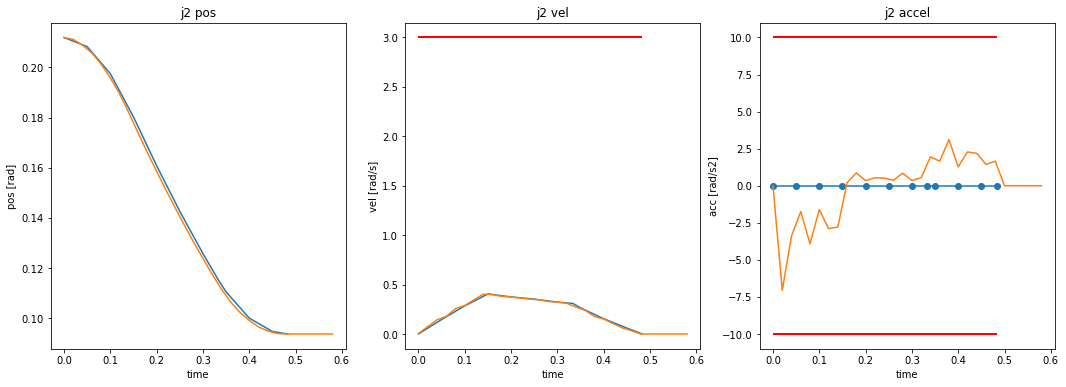

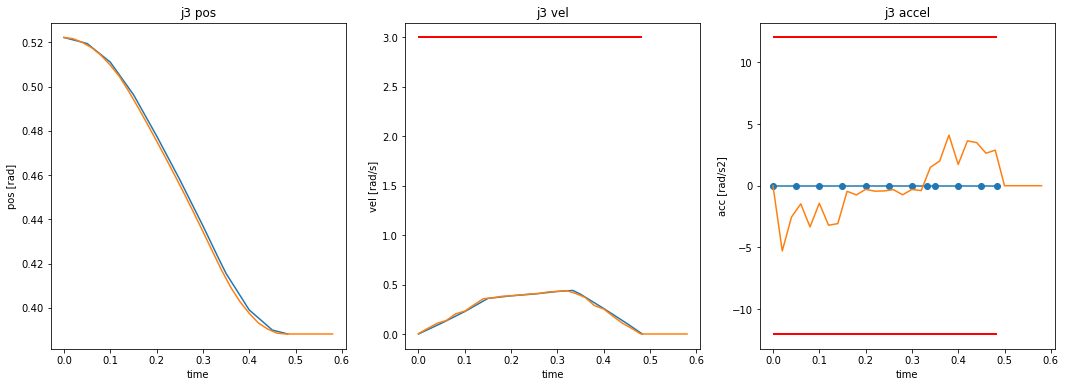

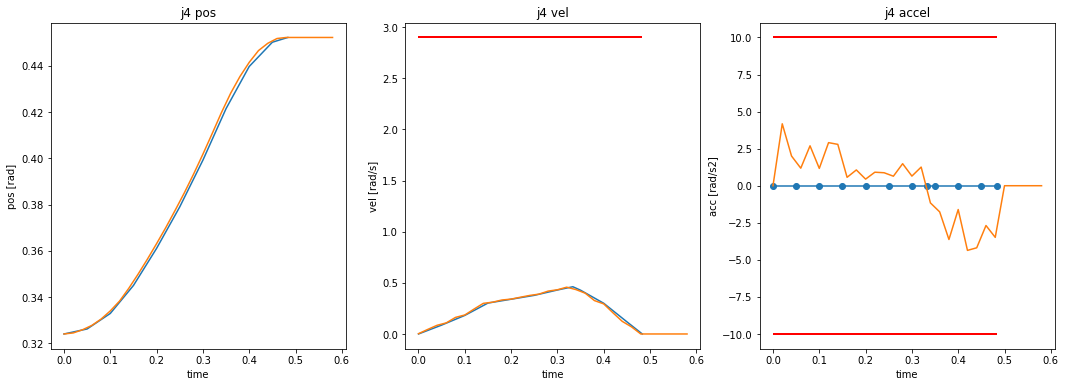

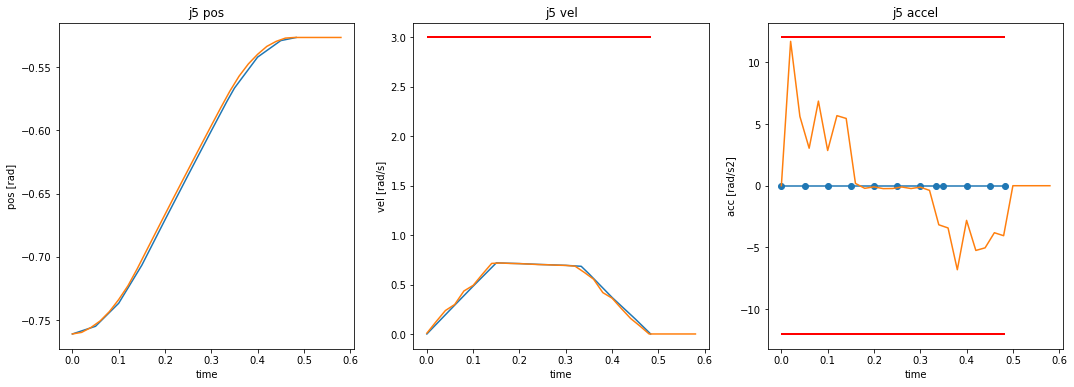

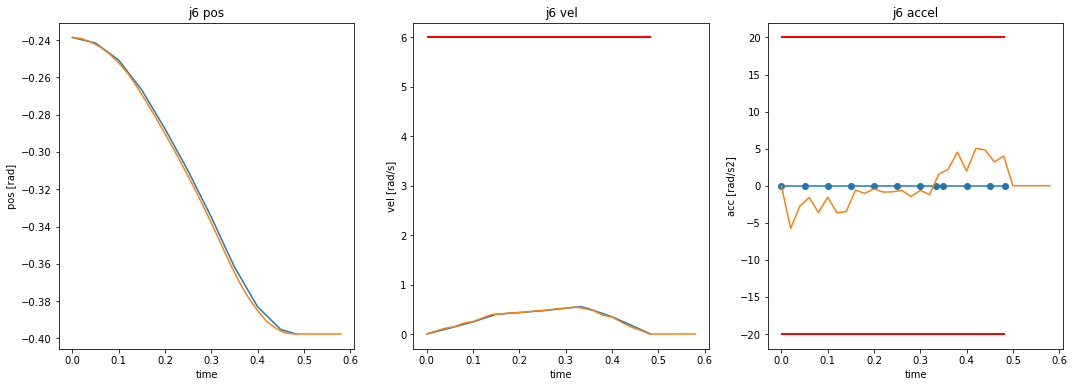

In [9]:
def get_limits(name):
    accel = rospy.get_param(
        f'/robot_description_planning/joint_limits/{name}/max_acceleration'
    )
    vel = rospy.get_param(
        f'/robot_description_planning/joint_limits/{name}/max_velocity'
    )
    return vel, accel

times = [point.time_from_start.to_sec() for point in trajectory_in.points]

for i in range(6):
    n = i+1
    max_vel, max_acc = get_limits(f"joint_{n}")
    plt.rcParams['figure.figsize'] = (18, 6)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
    ax = ax1
    pos = [point.positions[i] for point in trajectory_in.points]
    ax.plot(times, pos)
    ax.plot(times_out, [s.position[i] for s in trajectory_out])
    ax.set_title(f"j{n} pos")
    ax.set_xlabel("time")
    ax.set_ylabel("pos [rad]")
    ax = ax2
    vel = [abs(point.velocities[i]) for point in trajectory_in.points]
    ax.plot(times, vel)
    ax.plot(times_out, [abs(s.velocity[i]) for s in trajectory_out])
    ax.set_title(f"j{n} vel")
    ax.set_xlabel("time")
    ax.set_ylabel("vel [rad/s]")
    ax.hlines(y=max_vel, xmin=times[0], xmax=times[-1], linewidth=2, color='r')
    ax = ax3
    acc = [point.accelerations[i] for point in trajectory_in.points]
    ax.plot(times, acc, marker="o")
    accel = [0.0]
    accel.extend((trajectory_out[j].velocity[i] - trajectory_out[j-1].velocity[i]) / ((times_out[j] - times_out[j-1]) + (times_out[j-1] - times_out[max(0, j-2)])) * 2.0 for j in range(1, len(times_out)))
    ax.plot(times_out, accel)
    ax.set_title(f"j{n} accel")
    ax.set_xlabel("time")
    ax.set_ylabel("acc [rad/s2]")
    ax.hlines(y=max_acc, xmin=times[0], xmax=times[-1], linewidth=2, color='r')
    ax.hlines(y=-max_acc, xmin=times[0], xmax=times[-1], linewidth=2, color='r')

In [10]:
def calc_vel_accels(trajectory):
    times = [point.time_from_start.to_sec() for point in trajectory.points]
    j = 3
    vel = [0.0]
    vel.extend((trajectory.points[i].positions[j] - trajectory.points[i-1].positions[j]) / (times[i] - times[i-1]) for i in range(1, len(times)))
    accel = [0.0]
    accel.extend((vel[i] - vel[i-1]) / ((times[i] - times[i-1]) + (times[i-1] - times[max(0, i-2)])) * 2.0 for i in range(1, len(times)))
    return times, vel, accel
    
times, vels, accels = calc_vel_accels(trajectory_in)
print(max(abs(v) for v in vels))
print(max(abs(a) for a in accels))

0.44597714909725117
3.5557302574926735
